# Data Analysis
## GPLA-12

In [45]:
import pandas as pd

X = pd.read_csv("data/data_v1/data.csv", header=None)
y = pd.read_csv("data/data_v1/label.csv", header=None)

n = min(len(X), len(y))
X = X.iloc[:n].reset_index(drop=True)
y = y.iloc[:n].reset_index(drop=True)

y.columns = ["label"]

df = pd.concat([X, y], axis=1)

print("Merged shape:", df.shape)
print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Merged shape: (684, 1461)
Feature shape: (684, 1460)
Label shape: (684, 1)


# Let's check for class imbalance

In [46]:
class_counts = df["label"].value_counts().sort_index()

print("Class distribution:")
print(class_counts)

print("\nClass percentages (%):")
print((class_counts / class_counts.sum() * 100).round(2))

Class distribution:
label
1     57
2     57
3     57
4     57
5     57
6     57
7     57
8     57
9     57
10    57
11    57
12    57
Name: count, dtype: int64

Class percentages (%):
label
1     8.33
2     8.33
3     8.33
4     8.33
5     8.33
6     8.33
7     8.33
8     8.33
9     8.33
10    8.33
11    8.33
12    8.33
Name: count, dtype: float64


# Flag undersampled classes

In [47]:
mean_count = class_counts.mean()
threshold = 0.75 * mean_count

undersampled = class_counts[class_counts < threshold]

print("Mean samples per class:", mean_count)
print("Undersampling threshold:", threshold)

if undersampled.empty:
    print("No clearly undersampled classes.")
else:
    print("\n⚠️ Undersampled classes detected:")
    print(undersampled)

Mean samples per class: 57.0
Undersampling threshold: 42.75
No clearly undersampled classes.


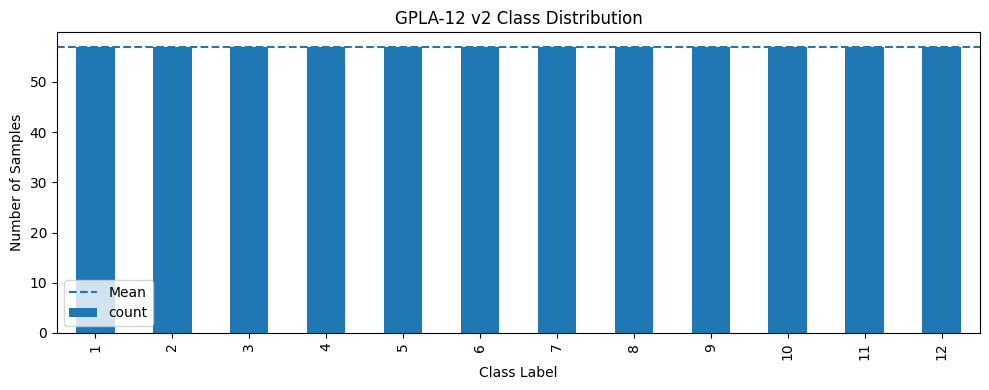

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
class_counts.plot(kind="bar")
plt.axhline(mean_count, linestyle="--", label="Mean")
plt.title("GPLA-12 v2 Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.legend()
plt.tight_layout()
plt.show()

# Seems pretty balanced, what about in-class diversity?

In [49]:
import numpy as np

# Separate features and labels
X = df.iloc[:, :-1].values
y = df["label"].values

class_sd = {}

for label in sorted(np.unique(y)):
    X_c = X[y == label]
    # std per feature, then mean over features
    class_sd[label] = X_c.std(axis=0).mean()

class_sd = pd.Series(class_sd)

print("Mean within-class SD per class:")
print(class_sd.round(4))

Mean within-class SD per class:
1     144.3468
2      80.8455
3     171.1359
4     132.5913
5     186.6017
6     154.6694
7     198.9350
8      88.8579
9     153.9879
10     96.1847
11    126.5253
12     95.3859
dtype: float64


In [50]:
global_sd = X.std(axis=0).mean()

print("Global mean SD:", round(global_sd, 4))
print("\nWithin-class SD / Global SD ratio:")
print((class_sd / global_sd).round(3))

Global mean SD: 426.3807

Within-class SD / Global SD ratio:
1     0.339
2     0.190
3     0.401
4     0.311
5     0.438
6     0.363
7     0.467
8     0.208
9     0.361
10    0.226
11    0.297
12    0.224
dtype: float64


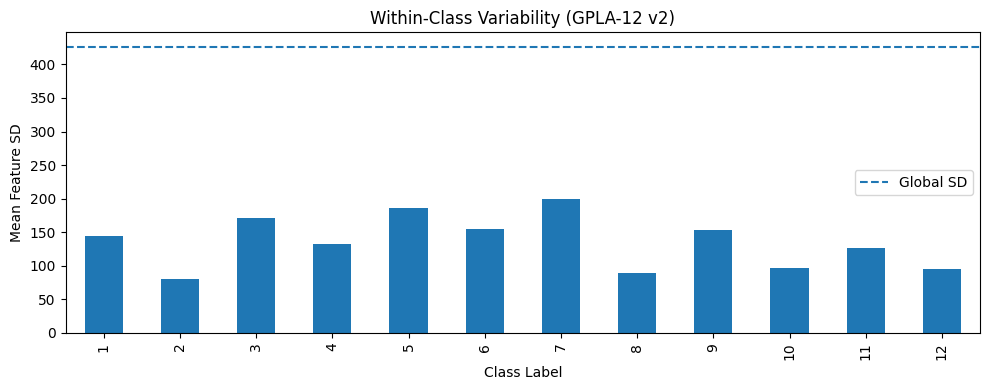

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
class_sd.plot(kind="bar")
plt.axhline(global_sd, linestyle="--", label="Global SD")
plt.title("Within-Class Variability (GPLA-12 v2)")
plt.xlabel("Class Label")
plt.ylabel("Mean Feature SD")
plt.legend()
plt.tight_layout()
plt.show()

# Coefficient of variation (CV)

In [52]:
class_cv = {}

for label in sorted(np.unique(y)):
    X_c = X[y == label]
    mean = X_c.mean(axis=0)
    std = X_c.std(axis=0)
    cv = std / (np.abs(mean) + 1e-8)
    class_cv[label] = np.nanmean(cv)

class_cv = pd.Series(class_cv)

print("Mean coefficient of variation per class:")
print(class_cv.round(3))

Mean coefficient of variation per class:
1     1.168
2     0.919
3     1.193
4     1.100
5     1.202
6     1.146
7     0.232
8     0.107
9     0.164
10    0.101
11    0.127
12    0.096
dtype: float64


# Let's check if any features are redundant
## Correlation Check:

In [53]:
X = df.iloc[:, :-1]

# Absolute Pearson correlation
corr = X.corr().abs()

# Upper triangle only
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Highly correlated feature pairs
redundant_pairs = [
    (col, upper[col].idxmax(), upper[col].max())
    for col in upper.columns
    if upper[col].max() > 0.95
]

redundant_pairs[:10]

[]

## Variance Check:

In [54]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=1e-5)
vt.fit(X)

low_variance_features = X.columns[~vt.get_support()]
len(low_variance_features)

0

## With Respect to Labels:

In [55]:
from sklearn.feature_selection import mutual_info_classif
y = df["label"]

mi = mutual_info_classif(X, y, random_state=42)
mi = pd.Series(mi, index=X.columns)

mi.sort_values(ascending=False).head(10)

198     0.864835
1243    0.863907
1318    0.861535
418     0.861338
547     0.859439
610     0.858032
968     0.857885
508     0.854839
762     0.854284
1270    0.853621
dtype: float64

## Intra-class vs Inter-class Variance Ratio:

In [56]:
def fisher_score(feature, labels):
    classes = np.unique(labels)
    overall_mean = feature.mean()

    num, den = 0, 0
    for c in classes:
        fc = feature[labels == c]
        num += len(fc) * (fc.mean() - overall_mean) ** 2
        den += fc.var()
    return num / (den + 1e-8)

fisher_scores = X.apply(lambda f: fisher_score(f.values, y.values))
fisher_scores.sort_values(ascending=False).head(10)

1457    632.558401
1224    605.010737
529     602.783595
330     595.211445
69      594.833993
431     587.598265
871     585.350655
606     583.162680
616     579.529140
1047    576.473046
dtype: float64

# Conclusion:
The data is overall pretty clean. Might only need normalization and zero-centring

# Let's start training!
## Splitting the data:

In [121]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, :-1].values
y = df["label"].values

# 20% test
X_train_gnb, X_test_gnb, y_train_gnb, y_test_gnb = train_test_split(
    X, y,
    test_size=0.1,
    stratify=y,
    shuffle=True,
    random_state=42
)

## Fitting the GNB Model:

In [122]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_gnb, y_train_gnb)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## Evaluation (No K-Folds):

In [123]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = gnb.predict(X_test_gnb)

print(classification_report(y_test_gnb, y_pred, digits=4))

              precision    recall  f1-score   support

           1     0.0000    0.0000    0.0000         5
           2     1.0000    1.0000    1.0000         6
           3     0.5714    0.6667    0.6154         6
           4     0.6667    0.6667    0.6667         6
           5     0.8571    1.0000    0.9231         6
           6     0.5000    0.5000    0.5000         6
           7     1.0000    1.0000    1.0000         6
           8     1.0000    1.0000    1.0000         6
           9     1.0000    1.0000    1.0000         6
          10     1.0000    1.0000    1.0000         5
          11     1.0000    1.0000    1.0000         5
          12     1.0000    1.0000    1.0000         6

    accuracy                         0.8261        69
   macro avg     0.7996    0.8194    0.8088        69
weighted avg     0.8054    0.8261    0.8149        69



In [124]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score, classification_report
X = df.iloc[:, :-1].values
y = df["label"].values

skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [125]:
macro_f1_scores = []
per_class_f1 = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    gnb = GaussianNB()
    gnb.fit(X_train, y_train)

    y_pred = gnb.predict(X_test)

    # Macro F1
    f1 = f1_score(y_test, y_pred, average="macro")
    macro_f1_scores.append(f1)

    # Per-class F1
    per_class_f1.append(
        f1_score(y_test, y_pred, average=None)
    )

    print(f"Fold {fold} | Macro-F1: {f1:.4f}")

Fold 1 | Macro-F1: 0.7704
Fold 2 | Macro-F1: 0.8310
Fold 3 | Macro-F1: 0.8368
Fold 4 | Macro-F1: 0.8540
Fold 5 | Macro-F1: 0.7991
Fold 6 | Macro-F1: 0.7530
Fold 7 | Macro-F1: 0.7786
Fold 8 | Macro-F1: 0.8170
Fold 9 | Macro-F1: 0.7949
Fold 10 | Macro-F1: 0.8680


In [126]:
macro_f1_scores = np.array(macro_f1_scores)

print(
    f"\nGNB Macro-F1 (5-fold CV): "
    f"{macro_f1_scores.mean():.4f} ± {macro_f1_scores.std():.4f}"
)


GNB Macro-F1 (5-fold CV): 0.8103 ± 0.0356


# CNN:
## Data Split:

In [127]:
import numpy as np
from sklearn.model_selection import train_test_split

X = df.iloc[:, :-1].values.astype(np.float32)
y = df["label"].values - 1

# 10% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.10,
    stratify=y,
    shuffle=True,
    random_state=42
)

# 10% validation (out of remaining 90%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1111,  # 0.1111 × 0.9 ≈ 0.10
    stratify=y_temp,
    shuffle=True,
    random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print("After unfurling")
print(X_train.shape, X_val.shape, X_test.shape)


(546, 1460) (69, 1460) (69, 1460)
After unfurling
(546, 1460, 1) (69, 1460, 1) (69, 1460, 1)


## CNN Architecture:

In [128]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AcousticCNN(nn.Module):
    def __init__(self, num_classes=12):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 32, kernel_size=9, padding=4)
        self.bn1   = nn.BatchNorm1d(32)
        self.drop1 = nn.Dropout1d(0.1)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=7, padding=3)
        self.bn2   = nn.BatchNorm1d(64)
        self.drop2 = nn.Dropout1d(0.2)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn3   = nn.BatchNorm1d(128)
        self.drop3 = nn.Dropout1d(0.3)

        self.pool = nn.MaxPool1d(2)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(128, 128)
        self.drop_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)

        x = self.pool(self.drop1(F.relu(self.bn1(self.conv1(x)))))
        x = self.pool(self.drop2(F.relu(self.bn2(self.conv2(x)))))
        x = self.pool(self.drop3(F.relu(self.bn3(self.conv3(x)))))

        x = self.global_pool(x).squeeze(-1)

        x = self.drop_fc(F.relu(self.fc1(x)))
        return self.fc2(x)

## Data loaders:

In [138]:
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

train_ds = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train)
)
val_ds = TensorDataset(
    torch.from_numpy(X_val),
    torch.from_numpy(y_val)
)
test_ds = TensorDataset(
    torch.from_numpy(X_test),
    torch.from_numpy(y_test)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

## Training & Evaluation:

In [187]:
model = AcousticCNN(num_classes=12).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
best_val_f1 = 0.0
best_state = None
patience = 100
patience_counter = 0

from sklearn.metrics import f1_score

def evaluate_f1(loader, model, device):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1).cpu().numpy()

            y_true.extend(yb.numpy())
            y_pred.extend(preds)

    return f1_score(y_true, y_pred, average="macro")



for epoch in range(1, 301):
    # -------- train --------
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    # -------- evaluate --------
    train_f1 = evaluate_f1(train_loader, model, device)
    val_f1   = evaluate_f1(val_loader, model, device)

    print(
        f"Epoch {epoch:03d} | "
        f"Train F1: {train_f1:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

    # -------- checkpoint --------
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered")
        break

Epoch 001 | Train F1: 0.1450 | Val F1: 0.1406
Epoch 002 | Train F1: 0.2838 | Val F1: 0.1950
Epoch 003 | Train F1: 0.5319 | Val F1: 0.5238
Epoch 004 | Train F1: 0.5764 | Val F1: 0.5500
Epoch 005 | Train F1: 0.5472 | Val F1: 0.5852
Epoch 006 | Train F1: 0.5502 | Val F1: 0.5083
Epoch 007 | Train F1: 0.6472 | Val F1: 0.6410
Epoch 008 | Train F1: 0.7041 | Val F1: 0.7053
Epoch 009 | Train F1: 0.7431 | Val F1: 0.6972
Epoch 010 | Train F1: 0.5482 | Val F1: 0.5518
Epoch 011 | Train F1: 0.5707 | Val F1: 0.5393
Epoch 012 | Train F1: 0.7410 | Val F1: 0.8198
Epoch 013 | Train F1: 0.7222 | Val F1: 0.6893
Epoch 014 | Train F1: 0.7214 | Val F1: 0.6583
Epoch 015 | Train F1: 0.6720 | Val F1: 0.6659
Epoch 016 | Train F1: 0.5487 | Val F1: 0.5343
Epoch 017 | Train F1: 0.6886 | Val F1: 0.6867
Epoch 018 | Train F1: 0.6320 | Val F1: 0.6422
Epoch 019 | Train F1: 0.6221 | Val F1: 0.5781
Epoch 020 | Train F1: 0.7373 | Val F1: 0.7189
Epoch 021 | Train F1: 0.6999 | Val F1: 0.7298
Epoch 022 | Train F1: 0.5830 | Val

## Results:

In [188]:
from sklearn.metrics import classification_report

model.eval()
y_true, y_pred = [], []
cnn = model

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        y_true.extend(yb.numpy())
        y_pred.extend(preds)

print(classification_report(y_true, y_pred, digits=4))
torch.save(cnn.state_dict(), "cnn_model.pth")

              precision    recall  f1-score   support

           0     1.0000    0.8000    0.8889         5
           1     1.0000    1.0000    1.0000         6
           2     0.8333    0.8333    0.8333         6
           3     1.0000    1.0000    1.0000         6
           4     0.8571    1.0000    0.9231         6
           5     1.0000    1.0000    1.0000         6
           6     1.0000    1.0000    1.0000         6
           7     0.6667    1.0000    0.8000         6
           8     0.8571    1.0000    0.9231         6
           9     0.2500    0.4000    0.3077         5
          10     1.0000    0.6000    0.7500         5
          11     0.0000    0.0000    0.0000         6

    accuracy                         0.8116        69
   macro avg     0.7887    0.8028    0.7855        69
weighted avg     0.7904    0.8116    0.7914        69



# Ensemble Model
## Probability Extractors:

In [189]:
def cnn_predict_proba(model, loader, device):
    model.eval()
    probs = []

    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            logits = model(xb)
            p = torch.softmax(logits, dim=1)
            probs.append(p.cpu().numpy())

    return np.vstack(probs)

def gnb_predict_proba(gnb_model, X):
    return gnb_model.predict_proba(X)

## Putting the Model Together:

In [190]:
TAIL_CLASSES = [8, 9, 10, 11]  # original classes 9–12
def ensemble_predict(
    cnn_probs,
    gnb_probs,
    gnb_thresh=0.5
):
    """
    cnn_probs, gnb_probs: (N, 12) probability arrays
    GNB dominates for classes 9–12 when confident
    """
    final_preds = np.zeros(len(cnn_probs), dtype=int)

    for i in range(len(cnn_probs)):
        # GNB's best tail-class prediction
        gnb_tail_idx = TAIL_CLASSES[np.argmax(gnb_probs[i, TAIL_CLASSES])]
        gnb_tail_conf = gnb_probs[i, gnb_tail_idx]

        if gnb_tail_conf >= gnb_thresh:
            # HARD OVERRIDE
            final_preds[i] = gnb_tail_idx
        else:
            # Default to CNN
            final_preds[i] = cnn_probs[i].argmax()

    return final_preds

## Evaluation of the Ensemble model:

In [191]:
from sklearn.metrics import classification_report

# CNN probabilities
cnn_probs = cnn_predict_proba(cnn, test_loader, device)

# GNB probabilities
gnb_probs = gnb_predict_proba(gnb, X_test_gnb)

# Ensemble prediction
y_pred_ens= ensemble_predict(
    cnn_probs,
    gnb_probs,
    gnb_thresh=0.5
)

print(
    classification_report(
        y_test,
        y_pred_ens,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     1.0000    0.8000    0.8889         5
           1     1.0000    1.0000    1.0000         6
           2     0.8333    0.8333    0.8333         6
           3     1.0000    1.0000    1.0000         6
           4     0.8571    1.0000    0.9231         6
           5     1.0000    1.0000    1.0000         6
           6     1.0000    1.0000    1.0000         6
           7     1.0000    1.0000    1.0000         6
           8     1.0000    1.0000    1.0000         6
           9     1.0000    1.0000    1.0000         5
          10     1.0000    1.0000    1.0000         5
          11     1.0000    1.0000    1.0000         6

    accuracy                         0.9710        69
   macro avg     0.9742    0.9694    0.9704        69
weighted avg     0.9731    0.9710    0.9708        69

